### Descomposicion y Pronostico Taller de Series de Tiempo

**Descripción**

Este conjunto de datos contiene información sobre la popularidad y el nivel de interés en diversos lenguajes de programación a lo largo del tiempo, medidos a partir del número total de preguntas realizadas en Stack Overflow entre los años 2008 y 2024.

El dataset permite analizar la evolución de los lenguajes de programación y comprender las tendencias y dinámicas cambiantes dentro del ecosistema del desarrollo de software. A través de estos datos, es posible identificar cómo varían las preferencias e intereses de los desarrolladores a nivel mundial, reflejando la adopción, crecimiento o declive de distintas tecnologías a lo largo de los años.

In [1]:
# vamos a leer la base de datos de Stack Overflow sobre preguntas de lenguajes de programación
import pandas as pd

# Leer el archivo CSV con los datos de Stack Overflow
df = pd.read_csv("TotalQuestions.csv")

# Mostrar las primeras filas del DataFrame
df.head()

,Month,C++,C#,TypeScript,PHP,Swift,Ruby,Go,SQL,Kotlin,...,Shell,C,HTML,Objective-C,Perl,Matlab,R,Python,Java,Javascript
0,2008-09-01,755,1639,0,474,0,286,0,503,0,...,65,320,328,50,130,11,6,537,634,1129
1,2008-11-01,734,1729,0,499,0,157,0,413,0,...,51,258,327,106,97,11,1,448,580,954
2,2008-12-01,630,1594,0,476,0,159,0,424,0,...,51,188,309,123,133,13,1,437,625,825
3,2009-01-01,848,2374,0,628,1,205,0,585,0,...,47,318,414,143,146,19,8,631,790,1147
4,2009-02-01,841,2597,0,757,1,286,0,668,0,...,75,331,480,209,163,27,8,630,945,1202


Vamos a interpretar nuestros datos

In [12]:
# numero total de registros
total_registros = df['Python'].count()
print(f"El número total de registros es: {total_registros}")
# temporalidades de la serie para python osea el rango de fechas
# fecha minima y maxima
fecha_minima = df['Month'].min()
fecha_maxima = df['Month'].max()
print(f"El rango de fechas para Python es: {fecha_minima} a {fecha_maxima}")

El número total de registros es: 185
El rango de fechas para Python es: 2008-09-01 00:00:00 a 2024-02-01 00:00:00


Osea tenemos fechas que van desde Noviembre de 2008 hasta Febrero de 2024. Ahora vamos a ajustar la temporalidad de los periodos. Solo tomemos el año y el mes de cada registro.


In [14]:
# primero saquemos una dt a parte solo con python para trabajar mas comodo
df_python = df[['Month', 'Python']].copy()
df_python.head()

,Month,Python
0,2008-09-01,537
1,2008-11-01,448
2,2008-12-01,437
3,2009-01-01,631
4,2009-02-01,630


In [17]:
# ahora si vamos a ajustar la temporalidad de los periodos. Solo tomemos el año y el mes de cada registro.
df_python['YearMonth'] = df_python['Month'].dt.to_period('M')
df_python.head()

,Month,Python,YearMonth
0,2008-09-01,537,2008-09
1,2008-11-01,448,2008-11
2,2008-12-01,437,2008-12
3,2009-01-01,631,2009-01
4,2009-02-01,630,2009-02


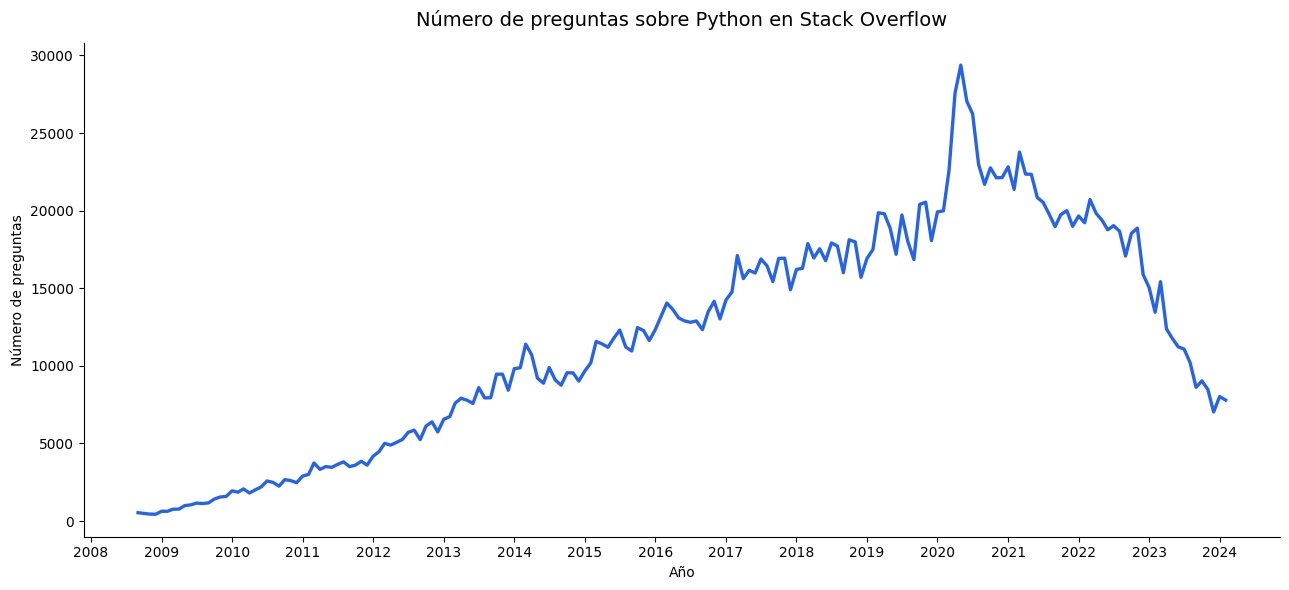

In [24]:
# bien ahora vamos a graficar la serie de tiempo con la nueva temporalida
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    df_python['Month'],
    df_python['Python'],
    color='#2563eb',
    linewidth=2.4
)

ax.set_title('Número de preguntas sobre Python en Stack Overflow', fontsize=14, pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Número de preguntas')

# formatear eje x para que muestre solo el año
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=0)

# limpieza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()